<a href="https://colab.research.google.com/github/Kunal-7O7/Machine-Learning-Algorithms/blob/main/K_NN_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Importing Basic libarary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [25]:
# importing a dataset for K_NN Algorithm

df=sns.load_dataset("titanic")

df1=df.copy()

In [26]:
# chekcing basics of data

print("Total_row & Columns:",df1.shape)
print("Targer_Variable:", "survived")


Total_row & Columns: (891, 15)
Targer_Variable: survived


In [27]:
# #Chekcing if all the columns are relevent in our model, As we can see that the who and adult_male has the same feature which is already
# can drive from sex so we can remvoe them and the pasenger class can also be drive from pclass so we can also remove class column
# the embarked and emnark_town also has the same feature so we can remove the embarl_town column as well and alive column will directly
# relate to our target veriabl so we also have to remove that.

df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [28]:
# after removing the irrelevent coliumns

df1.drop(["class","who","adult_male","embark_town","alive"],axis=1,inplace=True)


In [29]:
# Now to check how many missing values are present in out dataset

Missing=df1.isnull().sum()

Missing_value=Missing[Missing>0]

Missing_value

,0
age,177
embarked,2
deck,688


In [30]:
#  From Above Code we can see that there are some missing values in percentages of missing values
missing2=(df1.isnull().mean().mul(100).sort_values(ascending=False).round(2))
print(missing2[missing2>0])

deck        77.22
age         19.87
embarked     0.22
dtype: float64


In [31]:
# As deck column has a very high missing value so insteated of filling it we will also remove them from the datafram

df1.drop("deck",axis=1,inplace=True)

In [32]:
# There are some missing values in two columns now we will filla them using medium as the medium will give use the mid value for age
# for embarked we will fill it with

df1['age']=df1["age"].fillna(df["age"].median())
df1['embarked']=df1["embarked"].fillna(df["embarked"].mode()[0])


In [33]:
df1.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


In [35]:
# As we can see that now there are still some categorical columns and to building a Ml modela all columns should be of numrical form
# so we convert them into numrical columns instead of categorical by Encoders

df1["sex"]=df1["sex"].map({"male":1,
                           "female":0})

df1=pd.get_dummies(df1,columns=["embarked"],drop_first=True,dtype=int)

In [36]:
df1

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,0,1
1,1,1,0,38.0,1,0,71.2833,False,0,0
2,1,3,0,26.0,0,0,7.9250,True,0,1
3,1,1,0,35.0,1,0,53.1000,False,0,1
4,0,3,1,35.0,0,0,8.0500,True,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,True,0,1
887,1,1,0,19.0,0,0,30.0000,True,0,1
888,0,3,0,28.0,1,2,23.4500,False,0,1
889,1,1,1,26.0,0,0,30.0000,True,0,0


In [37]:
x=df1.drop("survived",axis=1)
y=df1["survived"]

In [38]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [40]:
# chekcing the shape of the train and test data
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(712, 9) (179, 9)
(712,) (179,)


In [41]:
# before builidng the model we also have to scale the value as knn is also a distance based algorithms

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [43]:
x_train.head()

,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
331,1,1,45.5,0,0,28.5000,True,0,1
733,2,1,23.0,0,0,13.0000,True,0,1
382,3,1,32.0,0,0,7.9250,True,0,1
704,3,1,26.0,1,0,7.8542,False,0,1
813,3,0,6.0,4,2,31.2750,False,0,1


In [44]:
x_test.head()

,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
709,3,1,28.0,1,1,15.2458,False,0,0
439,2,1,31.0,0,0,10.5000,True,0,1
840,3,1,20.0,0,0,7.9250,True,0,1
720,2,0,6.0,0,1,33.0000,False,0,1
39,3,0,14.0,1,0,11.2417,False,0,0


In [45]:
# Now our data is ready for fitting the model

model=KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

KNeighborsClassifier()

In [46]:
# Now after fitting the model we will predict our values

y_pred=model.predict(x_test)

In [51]:
# now comes the cheking the accuracy part

print("Accuracy_Score:",accuracy_score(y_test,y_pred))
print("-"*50)
print("Confusion_Matrix: ",confusion_matrix(y_test,y_pred))
print("-"*50)
print("Classification_Report:",classification_report(y_test,y_pred))


Accuracy_Score: 0.6871508379888268
--------------------------------------------------
Confusion_Matrix:  [[85 20]
 [36 38]]
--------------------------------------------------
Classification_Report:               precision    recall  f1-score   support

           0       0.70      0.81      0.75       105
           1       0.66      0.51      0.58        74

    accuracy                           0.69       179
   macro avg       0.68      0.66      0.66       179
weighted avg       0.68      0.69      0.68       179



Confusion_Matrix:  [[85 20]
 [36 38]]


In [50]:
print("Classification_Report:",classification_report(y_test,y_pred))

Classification_Report:               precision    recall  f1-score   support

           0       0.70      0.81      0.75       105
           1       0.66      0.51      0.58        74

    accuracy                           0.69       179
   macro avg       0.68      0.66      0.66       179
weighted avg       0.68      0.69      0.68       179



In [54]:
# Now by chekcing the accuracy score we find that is accuracy is not so good so we can change the parameeter and see the best value of k

accuracy=[]

for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy.append(accuracy_score(y_test,y_pred))



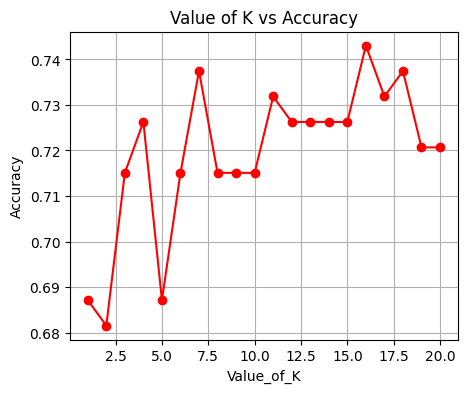

In [58]:
#Ploting the accuracy Score

plt.figure(figsize=(5,4))
plt.plot(range(1,21),accuracy,color="red",marker="o")

plt.title("Value of K vs Accuracy")
plt.xlabel("Value_of_K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [68]:
# Checking the best accuracy


best_k = np.argmax(accuracy) + 1
best_accuracy = max(accuracy)

print("Best K:", best_k)
print("Best Accuracy:", (best_accuracy)*100)


Best K: 16
Best Accuracy: 74.30167597765363
